1 0.020044116179148357
2*x^2 - 4*x - 23
2 0.020943220456441244
2*x^3 - 6*x^2 - 69*x + 219
3 0.021001283327738443
2*x^4 - 8*x^3 - 138*x^2 + 876*x + 113853
4 0.02134123643239339
2*x^5 - 10*x^4 - 230*x^3 + 2190*x^2 + 569265*x - 13050637
5 0.021362900733947754
6 0.021390151977539063
7 0.02141960064570109
8 0.02144963343938192
9 0.021486767133076987
10 0.0215317169825236
11 0.021585917472839354
12 0.02165166934331258
13 0.021745999654134113
14 0.021828718980153403
15 0.02192045052846273
16 0.022038483619689943
17 0.02215890089670817
18 0.02230733633041382
19 0.02247996727625529
20 0.022653969128926595
21 0.022849067052205404
22 0.023052720228830974
23 0.023262548446655273
24 0.02351113557815552
25 0.023792819182078043
26 0.02408583164215088
27 0.024399550755818684
28 0.024719051520029702
29 0.025063832600911457
30 0.025431386629740396
31 0.025830248991648357
32 0.026288183530171712
33 0.026771636803944905
34 0.027455814679463706
35 0.028056601683298748
36 0.02872811953226725
37 0.0293985009

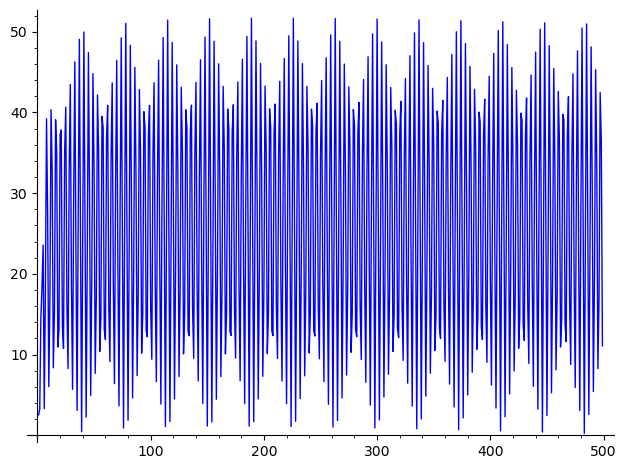

length: 499


In [2]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time
from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

start=time.time()

with open('/Users/barrybrent/data2/run15may26no17.txt', 'rb') as rfile:
    charpol_2B = pickle.load(rfile)
# from 'tauprime c=1 speedup tests 15may26'

with open('/Users/barrybrent/data2/run16may26no4.txt', 'rb') as rfile:
    charpol_48B = pickle.load(rfile)
# from   'pph c=1 17may26'

mins_list=[]
m = min(len(charpol_2B), len(charpol_48B))
for n in range(1, m):
    poly = charpol_2B[n][1] + charpol_48B[n][1]
    now=time.time()
    print(n,(now-start)/60)
    if n<5:
        print(poly) 
# almost certainly *not* what one finds if one adds the original h sequences
# and proceeds to compute the charpols.
# For example, in the latter case one expects the leading terms to = 1.
    roots = poly.roots(ring=CC, multiplicities=False)       
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()
print("length:",len(mins_list))
with open('/Users/barrybrent/data2/run24may26no2.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped


In [7]:
with open('/Users/barrybrent/data2/run16may26no4.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile) #fig 48B, `pph c=1 17may26'
for pair in mins_list[:3]:
    print(pair)

(1, x - 1)
(2, x^2 - 2*x)
(3, x^3 - 3*x^2 + 4)


Figure 2B analysis
Data range: n = 1 to 500
Number of data points: 500
Min modulus range: 0.251094 to 51.682877

Detrending: Savitzky-Golay filter, window = 31, poly order = 3
  lag-1 autocorrelation of residuals = 0.0388
  Detrended data std dev: 13.9168

AR(1) lag-1 autocorrelation (rho): 0.0388
Frequency bins tested: 247
Bonferroni-corrected per-bin alpha: 95% -> 0.000202,  99% -> 0.000040

SIGNIFICANT PERIODICITIES  (period <= N/3 = 167, Bonferroni-corrected)
Rank   Period       Frequency    Power           Signif.   
---------------------------------------------------------------------------
1            4.10   0.244000     1.32e+07   99%

  Only one significant peak (period = 4.10); no ratios to compute.


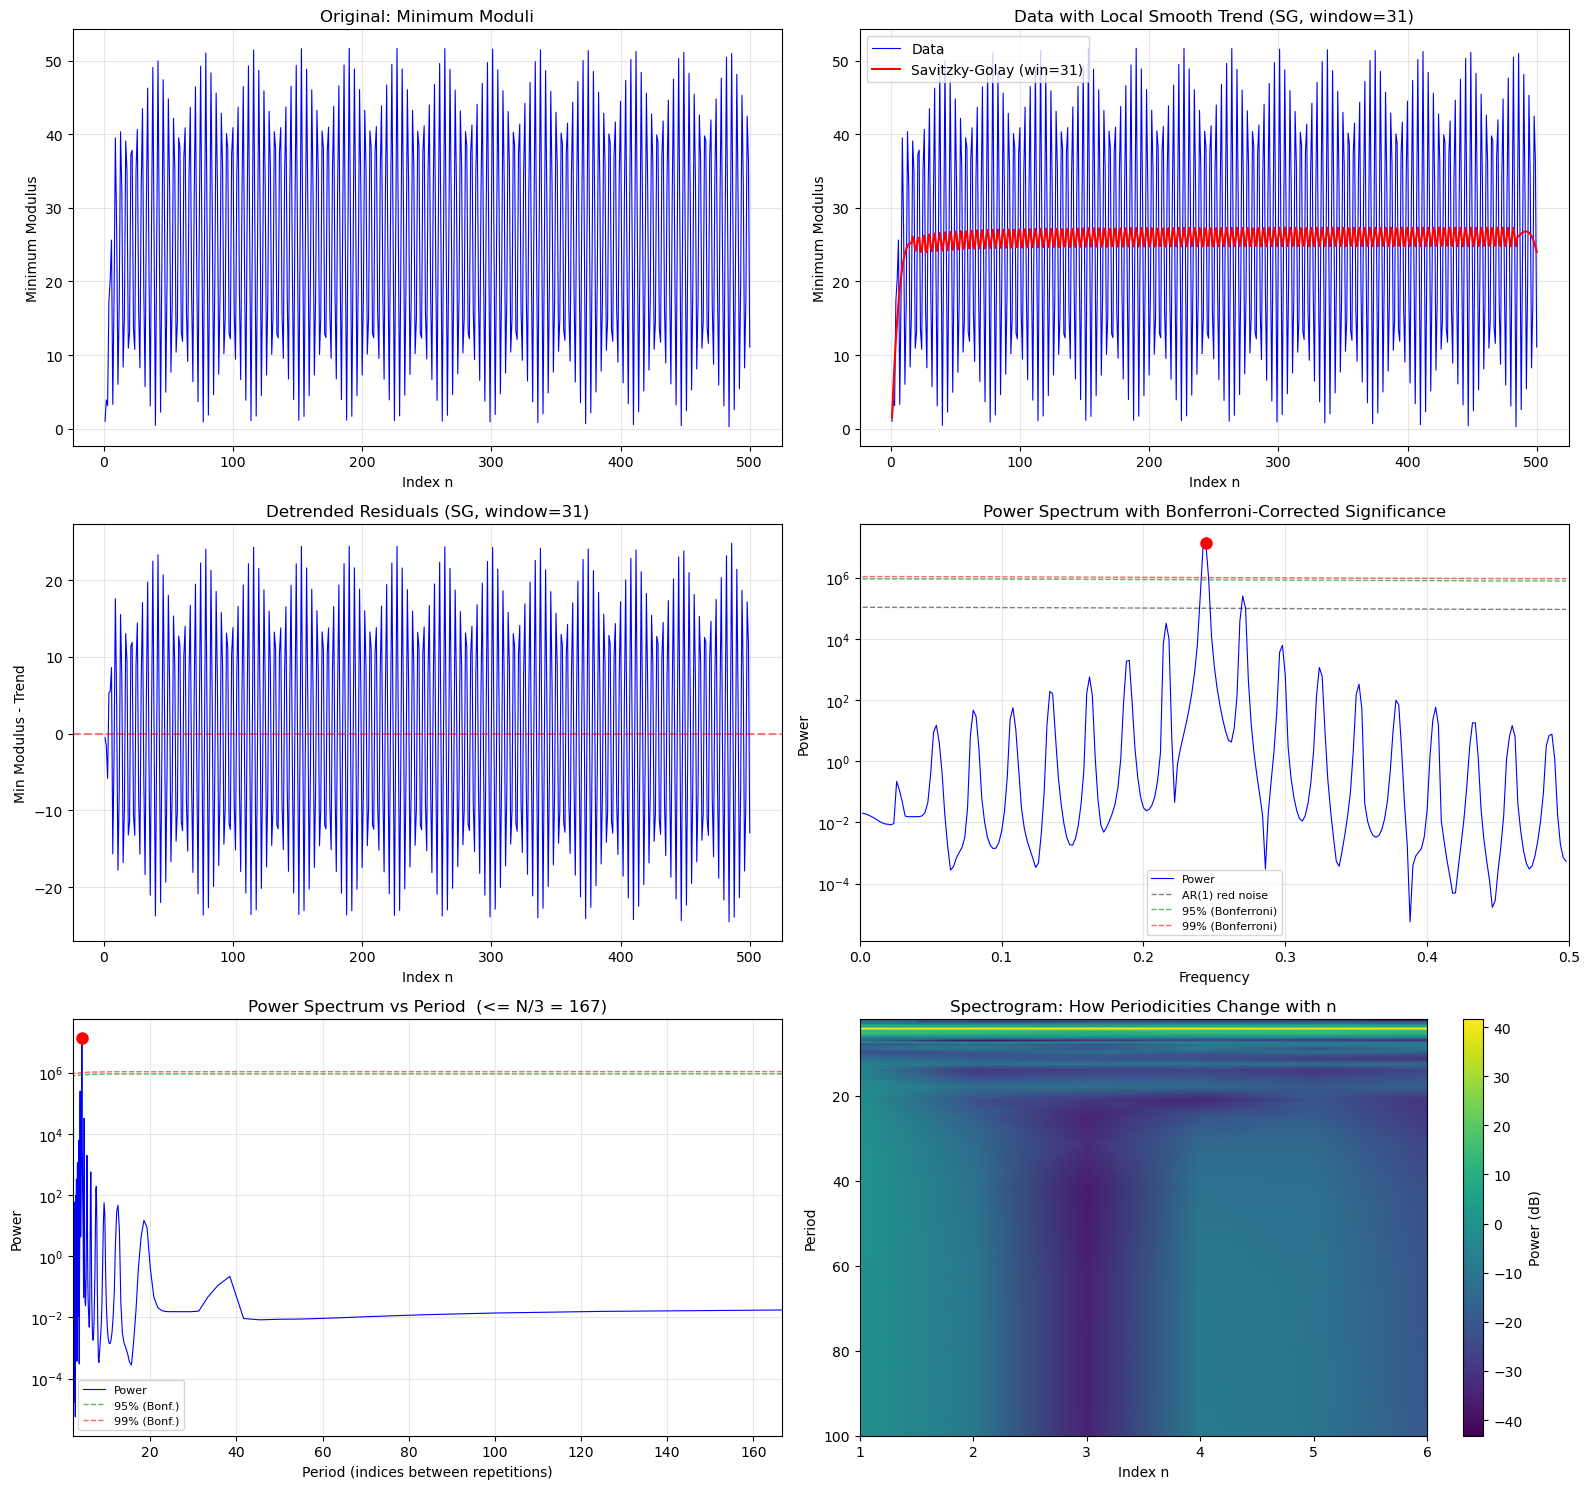


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run15may26no6.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile) #fig 2B, `tauprime c=1 speedup tests 15may26'

print("Figure 2B analysis")

# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v4)
#
# Key fix in this version: MULTIPLE TESTING CORRECTION.
#
# With N/2 ~ 175 frequency bins, a 95% single-bin threshold will produce
# ~9 false positives purely by chance, even for white noise. Previous
# versions didn't account for this, so plateau noise peaks were
# incorrectly flagged as "significant periodicities."
#
# This version applies a Bonferroni correction: the per-bin significance
# level is divided by the number of independent frequency bins tested,
# so the *family-wise* false positive rate stays at 5% (or 1%).
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. LOCAL SMOOTHING DETREND  (Savitzky-Golay)
# ==============================================================================
sg_poly_order = 3

candidate_windows = [w for w in range(21, min(N//2, 151), 10) if w % 2 == 1]

best_win, best_score = candidate_windows[0], np.inf
sg_results = {}
for win in candidate_windows:
    trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
    resid = minmoduli - trend
    r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
    sg_results[win] = (trend, resid, r1)
    if r1 < best_score:
        best_score = r1
        best_win = win

smooth_trend, detrended, _ = sg_results[best_win]

print(f"\nDetrending: Savitzky-Golay filter, window = {best_win}, poly order = {sg_poly_order}")
print(f"  lag-1 autocorrelation of residuals = {best_score:.4f}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = detrended * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
variance = np.var(detrended)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
max_credible_period = N / 3.0
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
# Per-bin alpha = family_alpha / n_tests
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

print("\n" + "="*75)
print(f"SIGNIFICANT PERIODICITIES  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
    # Period ratios: fundamental (rank 1) to each subsequent peak
    if len(significant_peaks) >= 2:
        fund_idx = significant_peaks[0][0]
        fund_period = periods[fund_idx]
        print(f"\n{'':>6}PERIOD RATIOS  (fundamental / peak)")
        print(f"{'':>6}Fundamental period: {fund_period:.2f}")
        print(f"{'':>6}{'-'*55}")
        print(f"{'':>6}{'Rank':<6} {'Period':<12} {'T_fund / T_peak':<18} {'Nearest int':<12}")
        print(f"{'':>6}{'-'*55}")
        for rank, (pi, level) in enumerate(significant_peaks[1:15], 2):
            ratio = fund_period / periods[pi]
            nearest = round(ratio)
            print(f"{'':>6}{rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     {nearest:>6}")
    elif len(significant_peaks) == 1:
        print(f"\n  Only one significant peak (period = {periods[significant_peaks[0][0]]:.2f}); "
              f"no ratios to compute.")
else:
    print("  No peaks exceed the Bonferroni-corrected significance threshold.")
    print("  --> The data has no statistically significant periodicity.")
    print("  (Period ratios are not computed when no peaks are significant.)")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=f'Savitzky-Golay (win={best_win})')
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Local Smooth Trend (SG, window={best_win})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals (SG, window={best_win})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Power spectrum with corrected confidence bands
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[1, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[1, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[1, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[1, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)

# 6.5  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[2, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[2, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[2, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[2, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_credible_period)

# 6.6  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(detrended, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[2, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_credible_period))
axes[2, 1].invert_yaxis()
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)


Figure48B analysis
Data range: n = 1 to 500
Number of data points: 500
Min modulus range: 0.000000 to 5.225736

Detrending: Savitzky-Golay filter, window = 21, poly order = 3
  lag-1 autocorrelation of residuals = 0.5795
  Detrended data std dev: 1.3149

AR(1) lag-1 autocorrelation (rho): 0.5795
Frequency bins tested: 247
Bonferroni-corrected per-bin alpha: 95% -> 0.000202,  99% -> 0.000040

SIGNIFICANT PERIODICITIES  (period <= N/3 = 167, Bonferroni-corrected)
Rank   Period       Frequency    Power           Signif.   
---------------------------------------------------------------------------
1            6.85   0.146000     1.08e+05   99%

  Only one significant peak (period = 6.85); no ratios to compute.


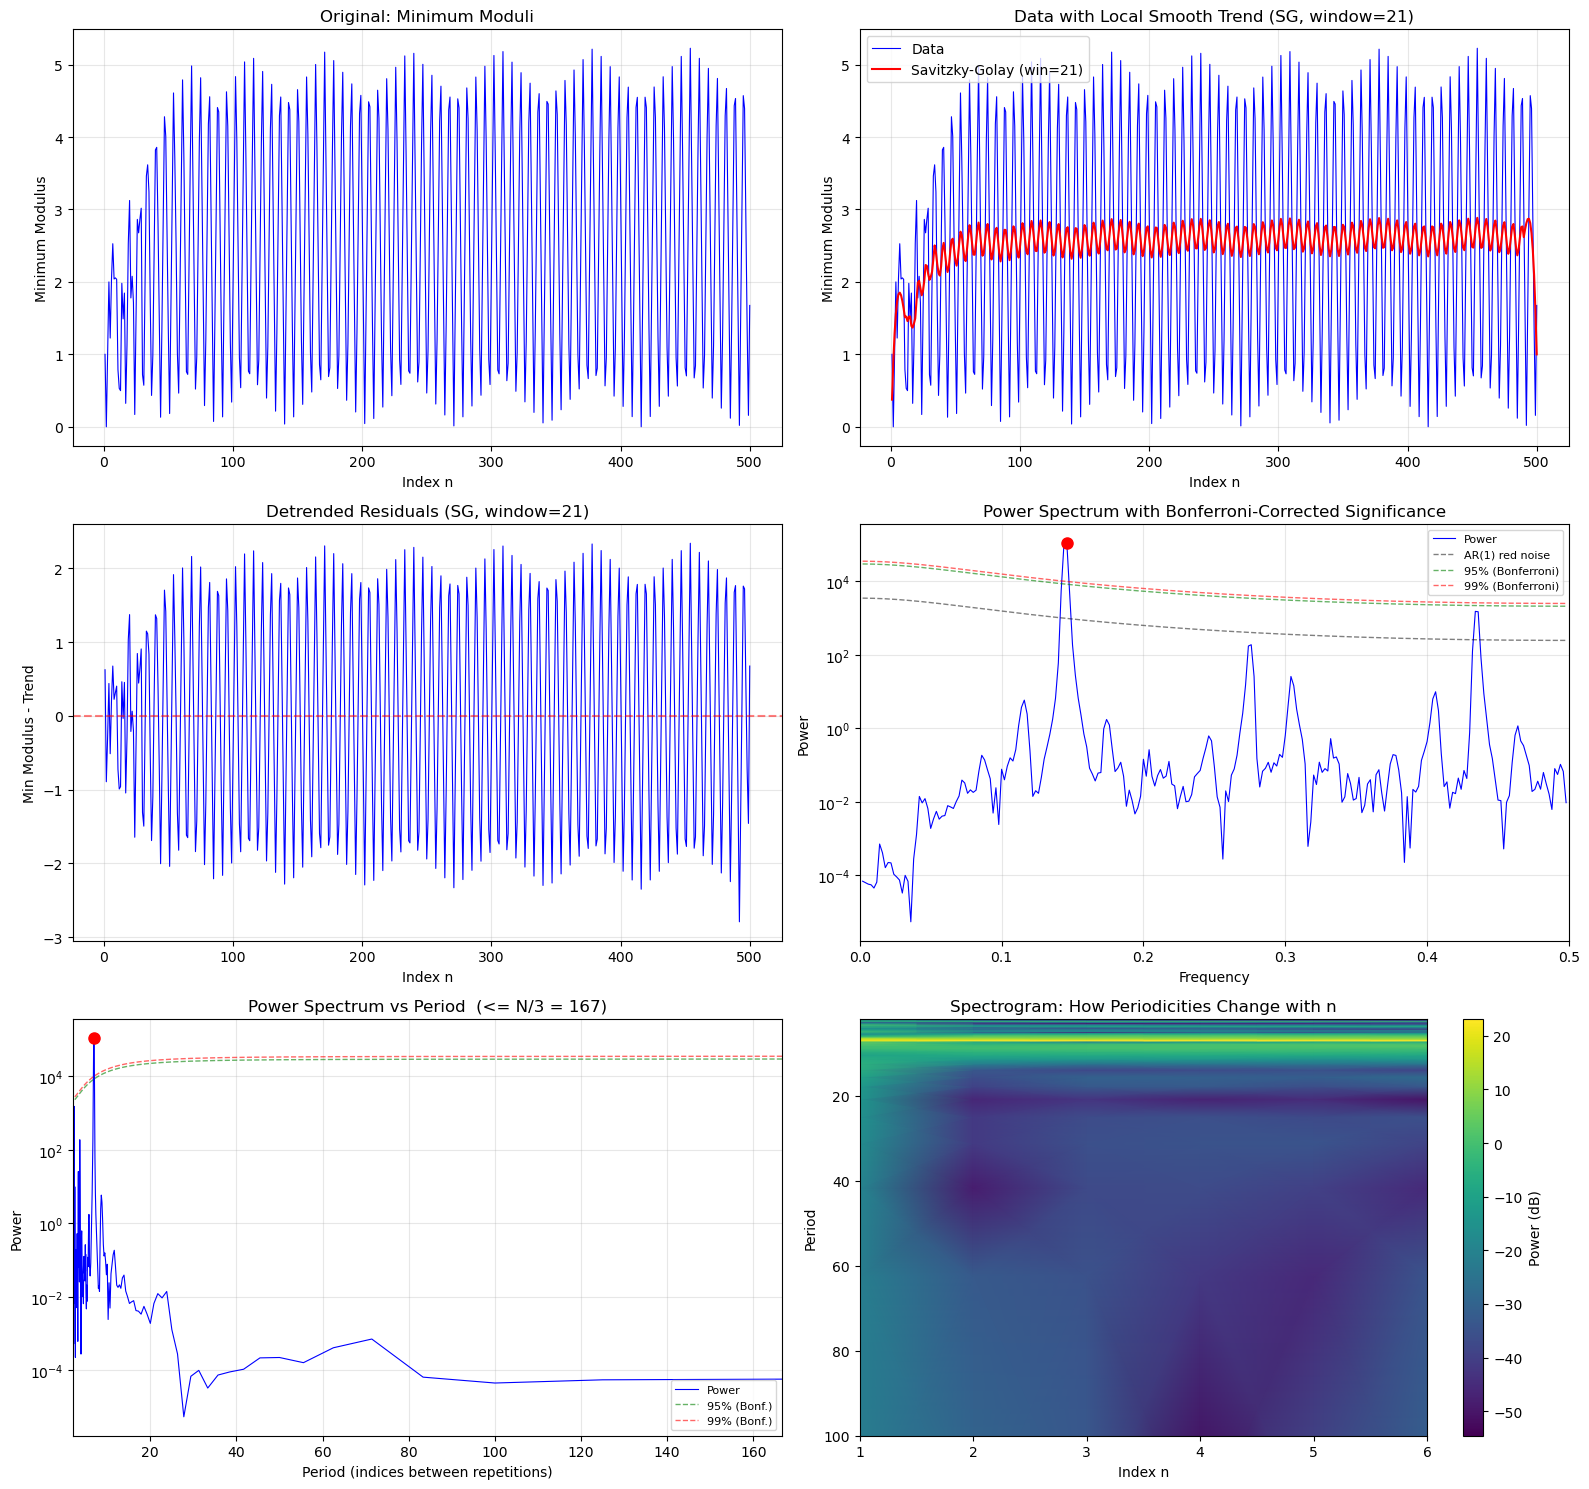


Analysis complete.


In [2]:
with open('/Users/barrybrent/data2/run16may26no3.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile) #fig 48B, `pph c=1 17may26'

print("Figure48B analysis")

# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v4)
#
# Key fix in this version: MULTIPLE TESTING CORRECTION.
#
# With N/2 ~ 175 frequency bins, a 95% single-bin threshold will produce
# ~9 false positives purely by chance, even for white noise. Previous
# versions didn't account for this, so plateau noise peaks were
# incorrectly flagged as "significant periodicities."
#
# This version applies a Bonferroni correction: the per-bin significance
# level is divided by the number of independent frequency bins tested,
# so the *family-wise* false positive rate stays at 5% (or 1%).
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. LOCAL SMOOTHING DETREND  (Savitzky-Golay)
# ==============================================================================
sg_poly_order = 3

candidate_windows = [w for w in range(21, min(N//2, 151), 10) if w % 2 == 1]

best_win, best_score = candidate_windows[0], np.inf
sg_results = {}
for win in candidate_windows:
    trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
    resid = minmoduli - trend
    r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
    sg_results[win] = (trend, resid, r1)
    if r1 < best_score:
        best_score = r1
        best_win = win

smooth_trend, detrended, _ = sg_results[best_win]

print(f"\nDetrending: Savitzky-Golay filter, window = {best_win}, poly order = {sg_poly_order}")
print(f"  lag-1 autocorrelation of residuals = {best_score:.4f}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = detrended * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
variance = np.var(detrended)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
max_credible_period = N / 3.0
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
# Per-bin alpha = family_alpha / n_tests
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

print("\n" + "="*75)
print(f"SIGNIFICANT PERIODICITIES  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
    # Period ratios: fundamental (rank 1) to each subsequent peak
    if len(significant_peaks) >= 2:
        fund_idx = significant_peaks[0][0]
        fund_period = periods[fund_idx]
        print(f"\n{'':>6}PERIOD RATIOS  (fundamental / peak)")
        print(f"{'':>6}Fundamental period: {fund_period:.2f}")
        print(f"{'':>6}{'-'*55}")
        print(f"{'':>6}{'Rank':<6} {'Period':<12} {'T_fund / T_peak':<18} {'Nearest int':<12}")
        print(f"{'':>6}{'-'*55}")
        for rank, (pi, level) in enumerate(significant_peaks[1:15], 2):
            ratio = fund_period / periods[pi]
            nearest = round(ratio)
            print(f"{'':>6}{rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     {nearest:>6}")
    elif len(significant_peaks) == 1:
        print(f"\n  Only one significant peak (period = {periods[significant_peaks[0][0]]:.2f}); "
              f"no ratios to compute.")
else:
    print("  No peaks exceed the Bonferroni-corrected significance threshold.")
    print("  --> The data has no statistically significant periodicity.")
    print("  (Period ratios are not computed when no peaks are significant.)")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=f'Savitzky-Golay (win={best_win})')
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Local Smooth Trend (SG, window={best_win})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals (SG, window={best_win})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Power spectrum with corrected confidence bands
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[1, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[1, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[1, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[1, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)

# 6.5  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[2, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[2, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[2, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[2, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_credible_period)

# 6.6  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(detrended, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[2, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_credible_period))
axes[2, 1].invert_yaxis()
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)



2B + 48B anylsis
Data range: n = 1 to 499
Number of data points: 499
Min modulus range: 0.251094 to 51.682877

Detrending: Savitzky-Golay filter, window = 31, poly order = 3
  lag-1 autocorrelation of residuals = 0.0392
  Detrended data std dev: 13.9290

AR(1) lag-1 autocorrelation (rho): 0.0392
Frequency bins tested: 246
Bonferroni-corrected per-bin alpha: 95% -> 0.000203,  99% -> 0.000041

SIGNIFICANT PERIODICITIES  (period <= N/3 = 166, Bonferroni-corrected)
Rank   Period       Frequency    Power           Signif.   
---------------------------------------------------------------------------
1            4.12   0.242485     1.34e+07   99%

  Only one significant peak (period = 4.12); no ratios to compute.


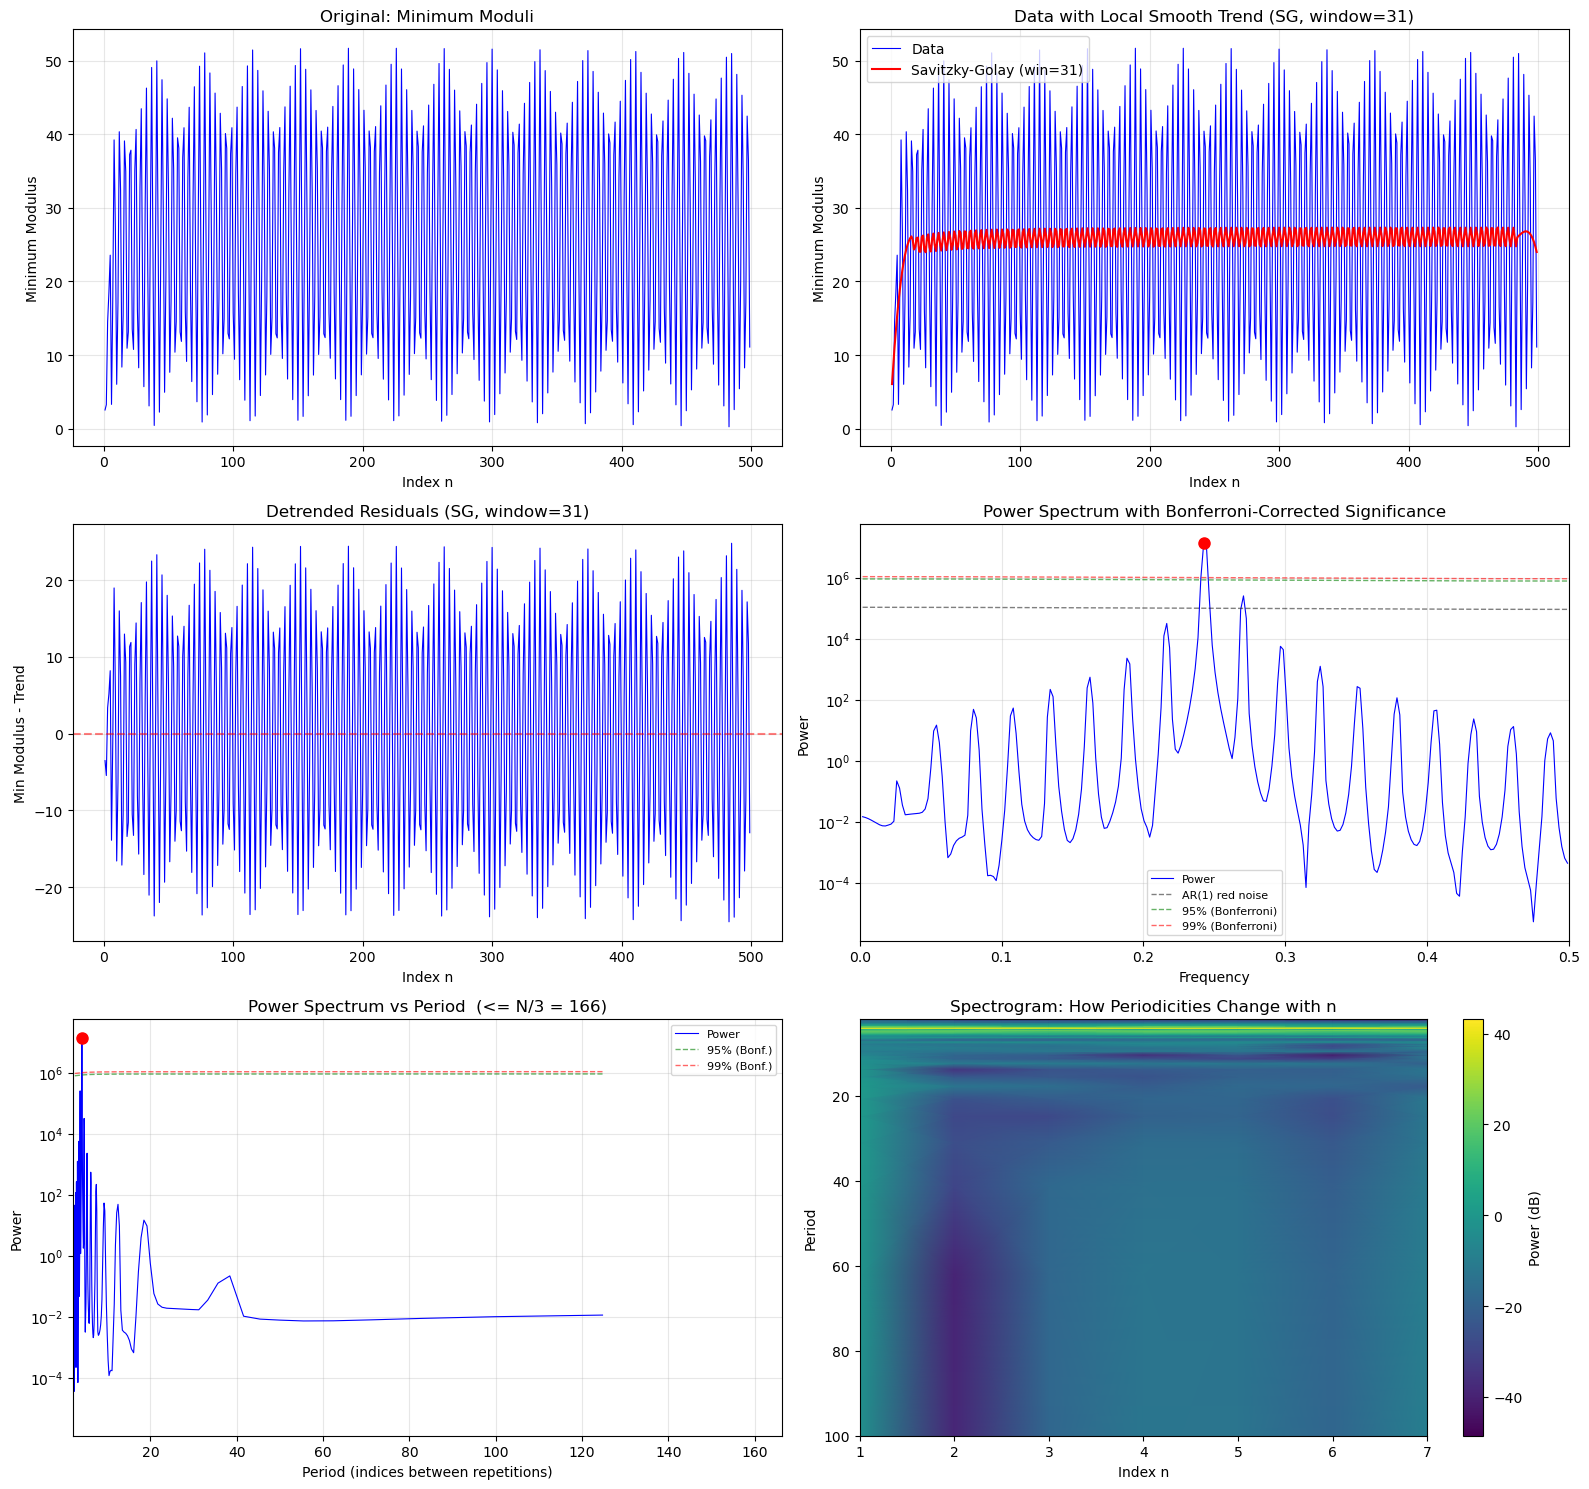


Analysis complete.


In [3]:
with open('/Users/barrybrent/data2/run24may26no2.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile) #12B + 48B

print("2B + 48B anylsis")

# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v4)
#
# Key fix in this version: MULTIPLE TESTING CORRECTION.
#
# With N/2 ~ 175 frequency bins, a 95% single-bin threshold will produce
# ~9 false positives purely by chance, even for white noise. Previous
# versions didn't account for this, so plateau noise peaks were
# incorrectly flagged as "significant periodicities."
#
# This version applies a Bonferroni correction: the per-bin significance
# level is divided by the number of independent frequency bins tested,
# so the *family-wise* false positive rate stays at 5% (or 1%).
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. LOCAL SMOOTHING DETREND  (Savitzky-Golay)
# ==============================================================================
sg_poly_order = 3

candidate_windows = [w for w in range(21, min(N//2, 151), 10) if w % 2 == 1]

best_win, best_score = candidate_windows[0], np.inf
sg_results = {}
for win in candidate_windows:
    trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
    resid = minmoduli - trend
    r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
    sg_results[win] = (trend, resid, r1)
    if r1 < best_score:
        best_score = r1
        best_win = win

smooth_trend, detrended, _ = sg_results[best_win]

print(f"\nDetrending: Savitzky-Golay filter, window = {best_win}, poly order = {sg_poly_order}")
print(f"  lag-1 autocorrelation of residuals = {best_score:.4f}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = detrended * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
variance = np.var(detrended)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
max_credible_period = N / 3.0
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
# Per-bin alpha = family_alpha / n_tests
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

print("\n" + "="*75)
print(f"SIGNIFICANT PERIODICITIES  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
    # Period ratios: fundamental (rank 1) to each subsequent peak
    if len(significant_peaks) >= 2:
        fund_idx = significant_peaks[0][0]
        fund_period = periods[fund_idx]
        print(f"\n{'':>6}PERIOD RATIOS  (fundamental / peak)")
        print(f"{'':>6}Fundamental period: {fund_period:.2f}")
        print(f"{'':>6}{'-'*55}")
        print(f"{'':>6}{'Rank':<6} {'Period':<12} {'T_fund / T_peak':<18} {'Nearest int':<12}")
        print(f"{'':>6}{'-'*55}")
        for rank, (pi, level) in enumerate(significant_peaks[1:15], 2):
            ratio = fund_period / periods[pi]
            nearest = round(ratio)
            print(f"{'':>6}{rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     {nearest:>6}")
    elif len(significant_peaks) == 1:
        print(f"\n  Only one significant peak (period = {periods[significant_peaks[0][0]]:.2f}); "
              f"no ratios to compute.")
else:
    print("  No peaks exceed the Bonferroni-corrected significance threshold.")
    print("  --> The data has no statistically significant periodicity.")
    print("  (Period ratios are not computed when no peaks are significant.)")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=f'Savitzky-Golay (win={best_win})')
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Local Smooth Trend (SG, window={best_win})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals (SG, window={best_win})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Power spectrum with corrected confidence bands
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[1, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[1, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[1, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[1, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)

# 6.5  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[2, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[2, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[2, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[2, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_credible_period)

# 6.6  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(detrended, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[2, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_credible_period))
axes[2, 1].invert_yaxis()
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)

